# **Modelo de Promedios Moviles**

[73, 4, 54, 61, 73, 1, 26, 59, 62, 35, 83, 20, 4, 66, 62, 41, 9, 31, 95, 46, 5, 53, 17, 77, 45, 48, 53, 36, 86, 33, 58, 22, 87, 38, 84, 46, 17, 58, 98, 30, 56, 78, 48, 5, 74, 0, 30, 17, 24, 38, 68, 46, 98, 30, 40, 85, 70, 57, 55, 60, 8, 83, 74, 41, 64, 20, 28, 52, 30, 4, 4, 63, 38, 77, 84, 9, 68, 10, 19, 49, 72, 47, 76, 19, 14, 99, 98, 12, 56, 21, 24, 44, 55, 53, 57, 31, 87, 35, 18, 79] 




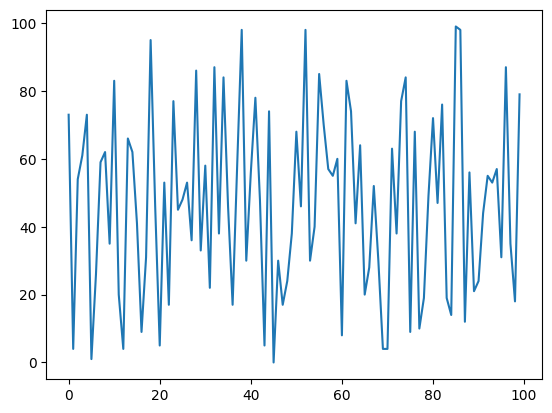

In [43]:
#importacion librerias
import random
import matplotlib.pyplot as plt

#generar data ficticia
data = []
n = 100
random.seed(10)
for i in range(n):
  data.append(random.randint(0, 100))

print(data, "\n"*2)

#ver "serie de tiempo"
plt.plot(data)

In [44]:
#crear funcion de promedios moviles
def moving_avg(n, k): #n = "dia" a predecir valor (van desde dia 0 a dia 100)  -- k = dias anterios a utilizar para el calculo
  acumm = []
  for i in range(k):
    if n < k:
      return
    else:
      acumm.append(data[n-(i+1)])
  val = sum(acumm)/k
  return val

n = 3
k = 2
moving_avg(n, k)

#Descripcion de la logica: si el dia a pronosticar es menor que la cantidad de dias anteriores a usar para el pronostico para la ejecucion. De lo contrario,
#añade al acumulador el valor de la posicion n-(i+1) (i+1 -> porque arranca desde 0 hasta k-1 (el range es excluyente)), donde n es el dia que se busca pronosticar y k
#la cantidad de dias anteriores que se utilizaran para hacer el pronostico. Cuando el bucle finaliza suma todos los datos dentro del acumulador (acumm) y los divide
#entre la cantidad de dias utilizados para la prediccion k (k = cantidad de datos dentro del acumulador). Finalmente retorna el pronostico.

29.0

-Calculos del error en el pronostico

In [45]:
calc_err = []
#crea una lista vacia para añadir los pronosticos del modelo
for i in range(12):
  calc_err.append(moving_avg(i, k))

In [46]:
print(calc_err)
calc_err = [x for x in calc_err if x is not None]
print(calc_err)
print(len(calc_err))
#elimina los None almacenam¿dos en la lista (estos None vienen de la restriccion establecida en la funcion (n no puede ser menor que k))

[None, None, 38.5, 29.0, 57.5, 67.0, 37.0, 13.5, 42.5, 60.5, 48.5, 59.0]
[38.5, 29.0, 57.5, 67.0, 37.0, 13.5, 42.5, 60.5, 48.5, 59.0]
10


In [47]:
#calcular error
ext_data = []
for i in range(len(calc_err) + k):  # +k para compensar los datos perdidos (None)
  ext_data.append(data[i])

print(ext_data)
ext_data = ext_data[k:] #se eliminan los k primeros registros para poder comparar adecuadamente el error (valor observado - pronosticado (no se puede comparar con None))
print(ext_data)

#----------------
error = []
for i in range(len(calc_err)):
  error.append((calc_err[i] - ext_data[i])**2)  #añade a la lista vacia la diferencia elevada al cuadrado de los valores en cada iteracion

RMSE = (sum(error)/len(calc_err))**0.5   #calcula el RMSE aplicando la formula (raiz cuadrada de la sumatoria de los errores al cuadrado entre el numero de errores)

print("\n"*2, "Predicciones:", calc_err)
print("Valores Observados", ext_data)
print("\n RMSE:", RMSE)

[73, 4, 54, 61, 73, 1, 26, 59, 62, 35, 83, 20]
[54, 61, 73, 1, 26, 59, 62, 35, 83, 20]


 Predicciones: [38.5, 29.0, 57.5, 67.0, 37.0, 13.5, 42.5, 60.5, 48.5, 59.0]
Valores Observados [54, 61, 73, 1, 26, 59, 62, 35, 83, 20]

 RMSE: 34.341665655585196


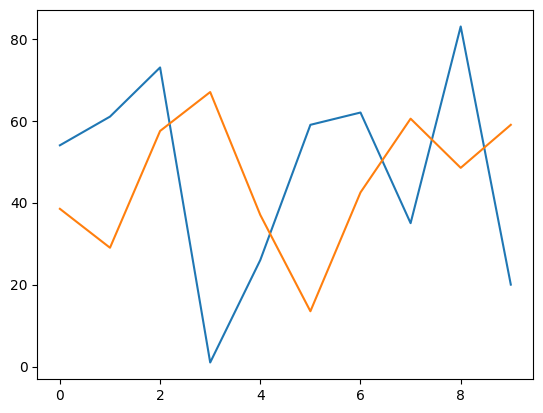

In [48]:
plt.plot(ext_data)
plt.plot(calc_err)

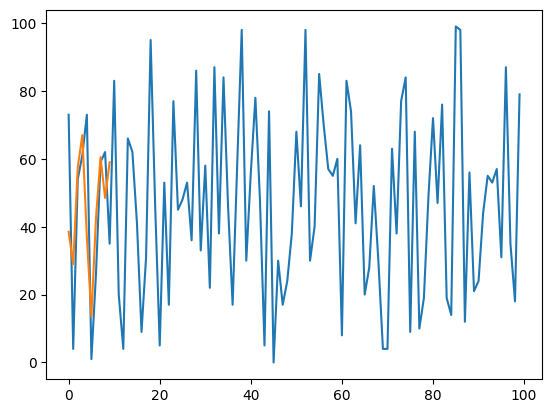

In [49]:
plt.plot(data)
plt.plot(calc_err)